In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10


c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\scipy\__init__.py:169: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
DATA_DIR = r'D:/indoor/Images'
model_algo="alexnet"

In [3]:
transform=transforms.Compose([
    transforms.Resize((224,224)),    
    transforms.ToTensor() 
])

In [4]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append(r'C:\Users\MJ\Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [5]:
#讀取資料且切分資料為train、valid、test

images=ImageDataset(DATA_DIR,transform,decision_mode=False)

generator = torch.Generator()
generator.manual_seed(124)

size = len(images)
valid_size = int(0.2 * size)

train_size = int(size - valid_size )

trainset, validset= random_split(images, (train_size, valid_size), generator=generator)


In [6]:
valid_size

3124

In [7]:
train_size

12496

In [8]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

In [9]:
# model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
model_0 = torch.load(f'model_{model_algo}_0_7.pth')

In [10]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.03791533887777453, 0.9915973111395646)

In [11]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(1.6732970050294025, 0.6203585147247119)

In [12]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [13]:
each_accu=2*p*r/(p+r)
each_accu

airport_inside    0.994893
artstudio         1.000000
auditorium        0.996337
bakery            0.995392
bar               0.990354
                    ...   
tv_studio         0.996016
videostore        0.988372
waitingroom       0.991803
warehouse         0.996188
winecellar        0.985577
Length: 67, dtype: float64

In [14]:
# each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
# each_accu

In [ ]:
each_accu[4]

In [15]:
targetF=[x  for x in each_accu.nsmallest(34).index.map(trainset.dataset.classess)]
targetF

[38,
 40,
 17,
 36,
 24,
 49,
 50,
 5,
 26,
 11,
 7,
 22,
 13,
 66,
 12,
 31,
 6,
 18,
 63,
 55,
 44,
 41,
 4,
 39,
 48,
 59,
 64,
 20,
 37,
 46,
 47,
 60,
 33,
 42]

In [16]:
# targetF=[2,4]

In [18]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('classaccu',targetF)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
len(indexF),len(indexT)

In [ ]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(1599, 1525)

In [ ]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [ ]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [ ]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,class_weight=None,trainclassnum=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,2)
    # elif(data_name=='T'or data_name=='F'):
    #     model=model_create(model_algo,data_name,len(train_dl.dataset.classes))
    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    elif(model_algo=='efficientnet_b7' or model_algo=='mobilenet_v2'):
        model_fc_layer=model.classifier[1]
    else:
        model_fc_layer=model.classifier[6]
        
    # for param in model.parameters():
    #     param.requires_grad = False

    # for param in model_fc_layer.parameters():
    #     param.requires_grad = True

    if(data_name=="decision"):
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        # dense1 = nn.Linear(9216, 224 * 224 * 3)
        # reshape = nn.Unflatten(-1,(3,224, 224))
        # model=nn.Sequential(dense1,reshape,model)
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    else:   
        optim = torch.optim.Adam(model.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    # torch.save(model, f"model_{model_algo}_{data_name}.pth")
    torch.cuda.empty_cache() 
    return model



Epoch=0,train_loss=0.13942526395357524,train_accu=0.961667733674776
Epoch=0,valid_loss=0.447023549931608,valid_accu=0.7954545454545454
0
Epoch=1,train_loss=0.053959972915572335,train_accu=0.9893565941101152
Epoch=1,valid_loss=0.4796586124448251,valid_accu=0.8085787451984635
0
Epoch=2,train_loss=0.029346703650685035,train_accu=0.9959987195902689
Epoch=2,valid_loss=0.523745634033799,valid_accu=0.8066581306017926
Epoch=3,train_loss=0.015115165339172287,train_accu=0.9980793854033291
Epoch=3,valid_loss=0.5462891042003558,valid_accu=0.8178617157490397
0
Epoch=4,train_loss=0.011113205948554184,train_accu=0.9977592829705506
Epoch=4,valid_loss=0.6163809000300995,valid_accu=0.8098591549295775
Epoch=5,train_loss=0.016709213436190064,train_accu=0.9951984635083226
Epoch=5,valid_loss=0.7266877835447138,valid_accu=0.7912932138284251
Epoch=6,train_loss=0.011129384818305763,train_accu=0.9971190781049936
Epoch=6,valid_loss=0.7014850590964743,valid_accu=0.8028169014084507
Epoch=7,train_loss=0.00369234378

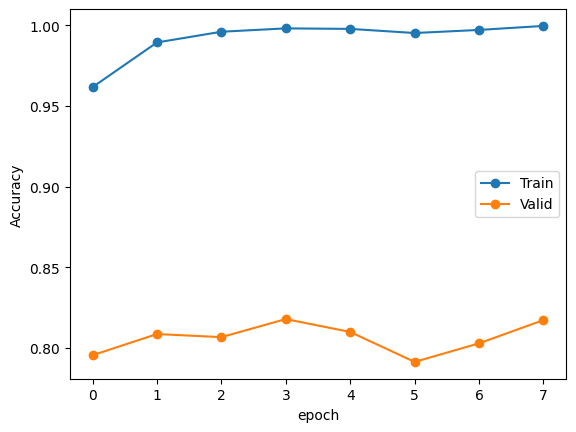

In [ ]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32)
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70,trainclassnum=len(trainset.dataset.classes))

In [ ]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.880989882779751,train_accu=0.7505077860528098
Epoch=0,valid_loss=1.162942500583461,valid_accu=0.6557377049180327
0
Epoch=1,train_loss=0.5257061638376885,train_accu=0.8436018957345972
Epoch=1,valid_loss=1.029252495687516,valid_accu=0.6931147540983607
0
Epoch=2,train_loss=0.2249741350970885,train_accu=0.942450914014895
Epoch=2,valid_loss=0.9366827028305804,valid_accu=0.7232786885245902
0
Epoch=3,train_loss=0.08808650504658976,train_accu=0.9786729857819905
Epoch=3,valid_loss=0.929388888937528,valid_accu=0.7383606557377049
0
Epoch=4,train_loss=0.05534942214331194,train_accu=0.987813134732566
Epoch=4,valid_loss=0.9608670448084347,valid_accu=0.7422950819672132
0
Epoch=5,train_loss=0.06160297810138483,train_accu=0.984427894380501
Epoch=5,valid_loss=1.1018561875233885,valid_accu=0.7337704918032787
Epoch=6,train_loss=0.024183802254946957,train_accu=0.9961069735951252
Epoch=6,valid_loss=1.0147325649026964,valid_accu=0.7383606557377049
Epoch=7,train_loss=0.00956386350427572,t

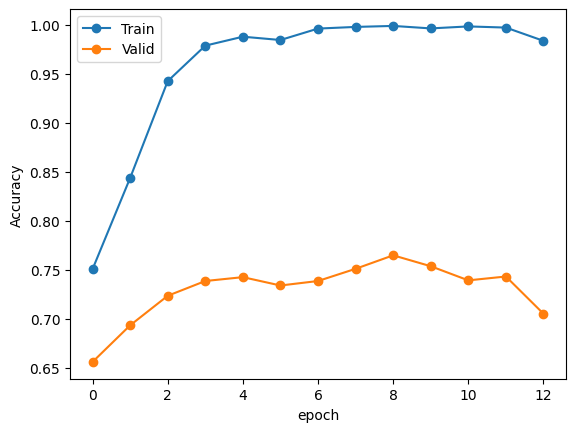

In [ ]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

In [ ]:
summary(model_T,(3,299,299))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 74, 74]          23,296
              ReLU-2           [-1, 64, 74, 74]               0
         MaxPool2d-3           [-1, 64, 36, 36]               0
            Conv2d-4          [-1, 192, 36, 36]         307,392
              ReLU-5          [-1, 192, 36, 36]               0
         MaxPool2d-6          [-1, 192, 17, 17]               0
            Conv2d-7          [-1, 384, 17, 17]         663,936
              ReLU-8          [-1, 384, 17, 17]               0
            Conv2d-9          [-1, 256, 17, 17]         884,992
             ReLU-10          [-1, 256, 17, 17]               0
           Conv2d-11          [-1, 256, 17, 17]         590,080
             ReLU-12          [-1, 256, 17, 17]               0
        MaxPool2d-13            [-1, 256, 8, 8]               0
AdaptiveAvgPool2d-14            [-1, 25

Epoch=0,train_loss=1.0630352529309777,train_accu=0.6903460837887068
Epoch=0,valid_loss=1.391280599353163,valid_accu=0.5809881175734835
0
Epoch=1,train_loss=0.6145202290961145,train_accu=0.8172434729811779
Epoch=1,valid_loss=1.255203639588705,valid_accu=0.6210131332082551
0
Epoch=2,train_loss=0.324967875000051,train_accu=0.9168184578020644
Epoch=2,valid_loss=1.1472045490337657,valid_accu=0.6572858036272671
0
Epoch=3,train_loss=0.18149713136857398,train_accu=0.9576502732240437
Epoch=3,valid_loss=1.240397676592547,valid_accu=0.6479049405878674
Epoch=4,train_loss=0.09481837252142505,train_accu=0.9820886460230722
Epoch=4,valid_loss=1.2381030416175527,valid_accu=0.6572858036272671
Epoch=5,train_loss=0.061487477587148065,train_accu=0.99013357619915
Epoch=5,valid_loss=1.32246803283095,valid_accu=0.6529080675422139
Epoch=6,train_loss=0.030397718002127386,train_accu=0.9948391013964785
Epoch=6,valid_loss=1.3793989861287348,valid_accu=0.6704190118824265
0
Epoch=7,train_loss=0.0394334242100707,trai

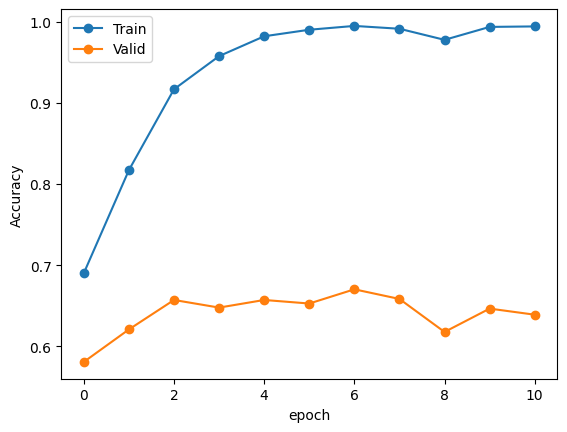

In [ ]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [ ]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.0049123166005050215, 0.9985595390524968)

In [ ]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.7325411397730037, 0.8137003841229193)

In [ ]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.007737892683259336, 0.9988151658767772)

In [ ]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.03039771808242356, 0.9948391013964785)

In [ ]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(1.081790692845329, 0.7645901639344262)

In [ ]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(1.379398977033342, 0.6704190118824265)

In [ ]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.019684817545084943, 0.9967189500640204, 6588)

In [ ]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(1.2341152947019218, 0.7163892445582587, 1599)

In [ ]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size,model_0,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_growth = model_0(data)

            softmax=torch.softmax(out_growth, dim=1)

            # out=model_decision(data)
            _, y_pred_tag = torch.max(out_growth, dim = 1)


            for pred,d,t in zip(y_pred_tag,data,target):

                if(pred in targetF):
                    outputs.append(model_F(d.unsqueeze(0)))
                    sum_F+=1
                else:
                    outputs.append(model_T(d.unsqueeze(0)))
                    sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [ ]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F)
total_train_loss,total_train_accu,sum_F,sum_T

(0.0726454824736287, 0.9943982074263764, 6587, 5909)

In [ ]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss,total_valid_accu,sum_F,sum_T

(4.467829996736651, 0.6216389244558259, 1637, 1487)

In [ ]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [ ]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.037915,0.991597,1.673297,0.620359
1,Model_Decision,0.004912,0.998560,0.732541,0.813700
2,Model_T,0.007738,0.998815,1.081791,0.764590
3,Model_F,0.030398,0.994839,1.379399,0.670419
4,Total_Model,0.072645,0.994398,4.467830,0.621639
5,Total_Model_without_decision,0.019685,0.996719,1.234115,0.716389


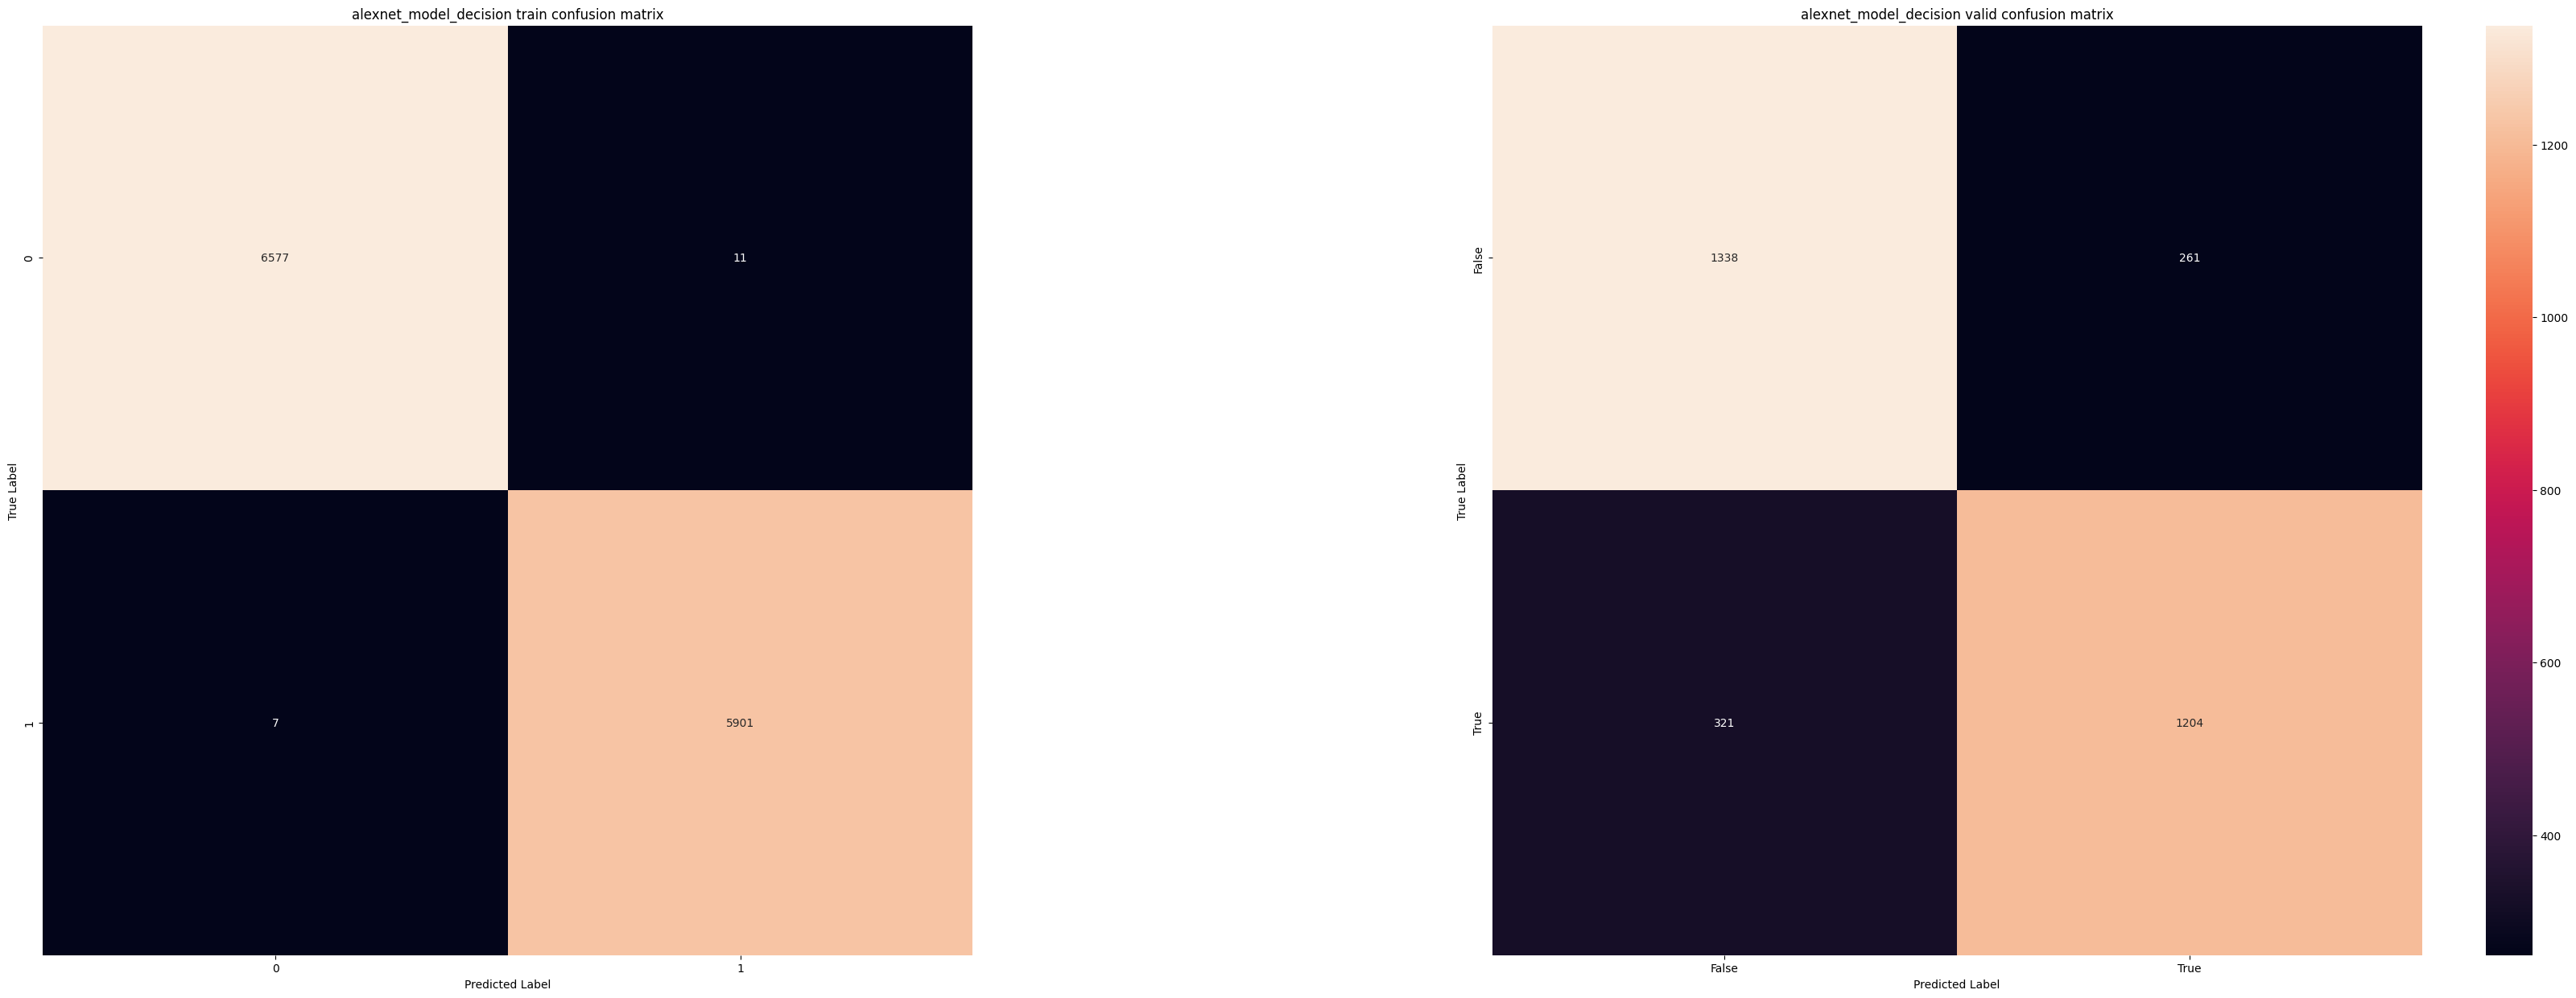

In [ ]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

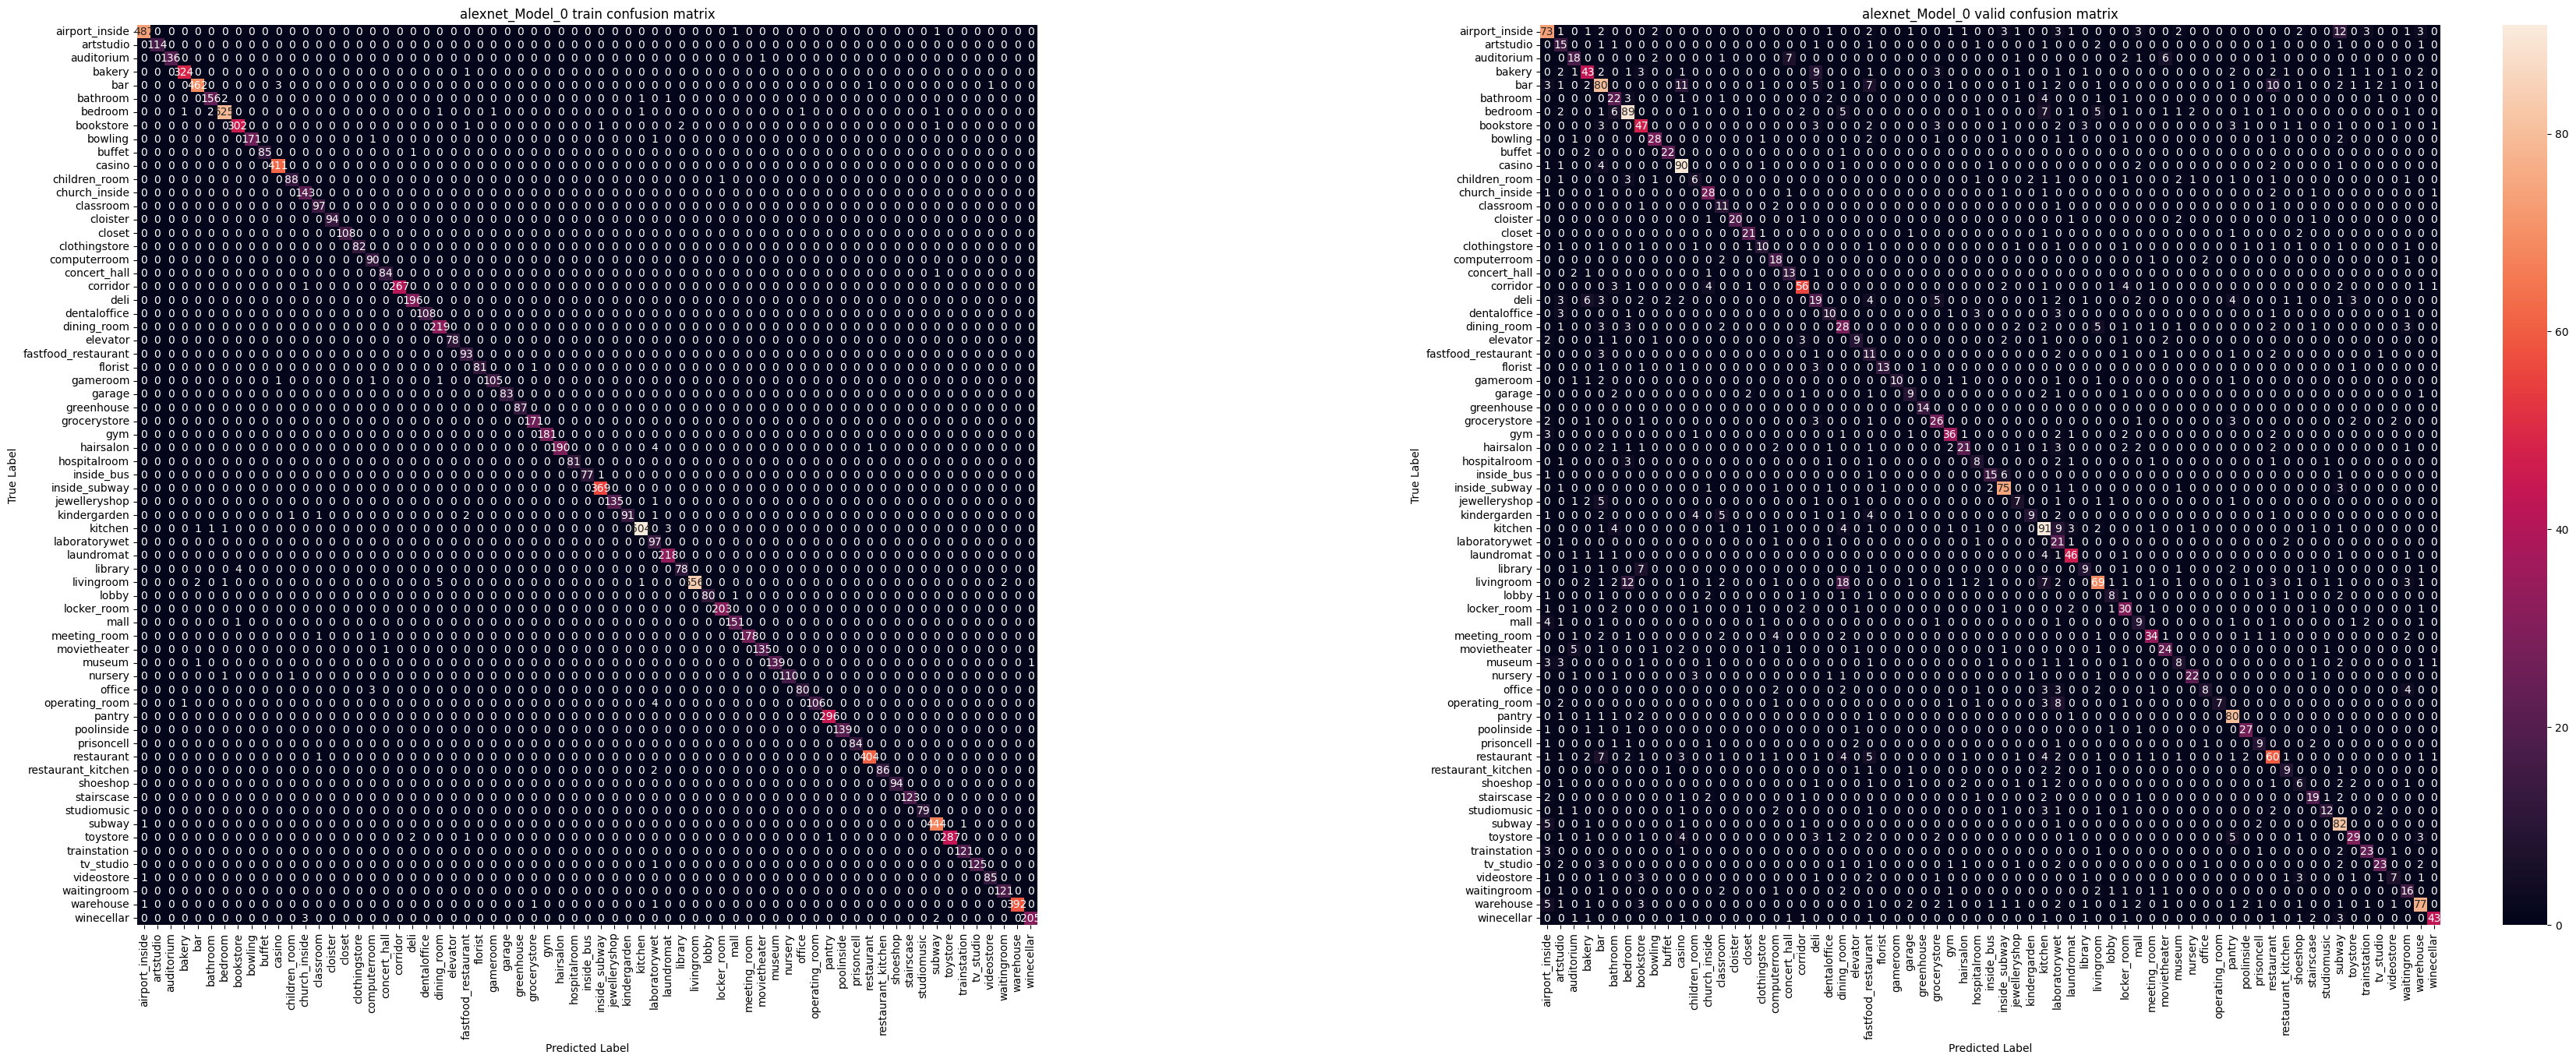

In [ ]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

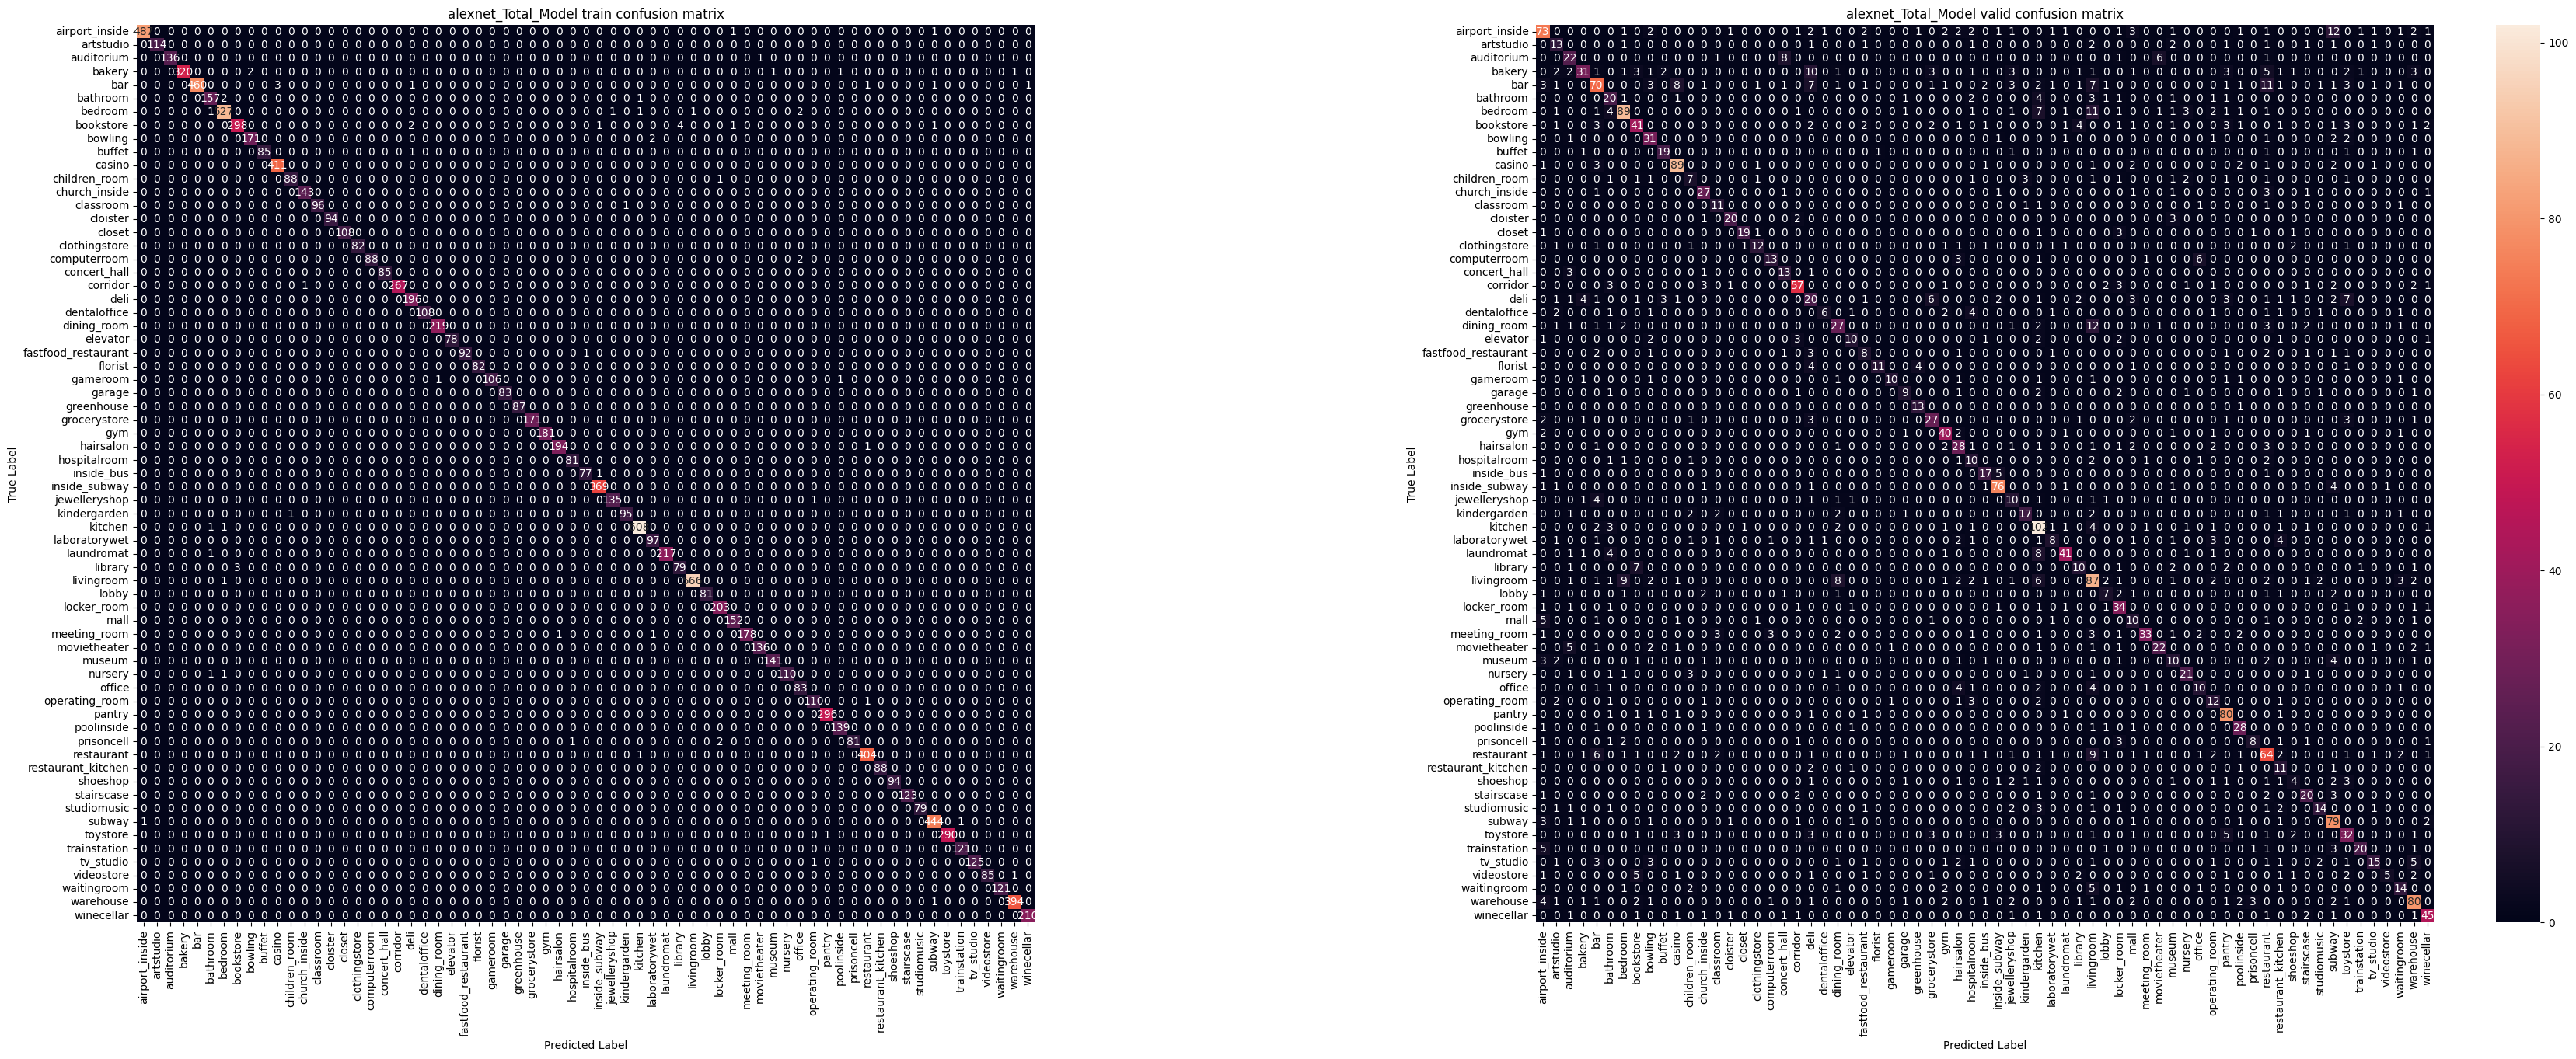

In [ ]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

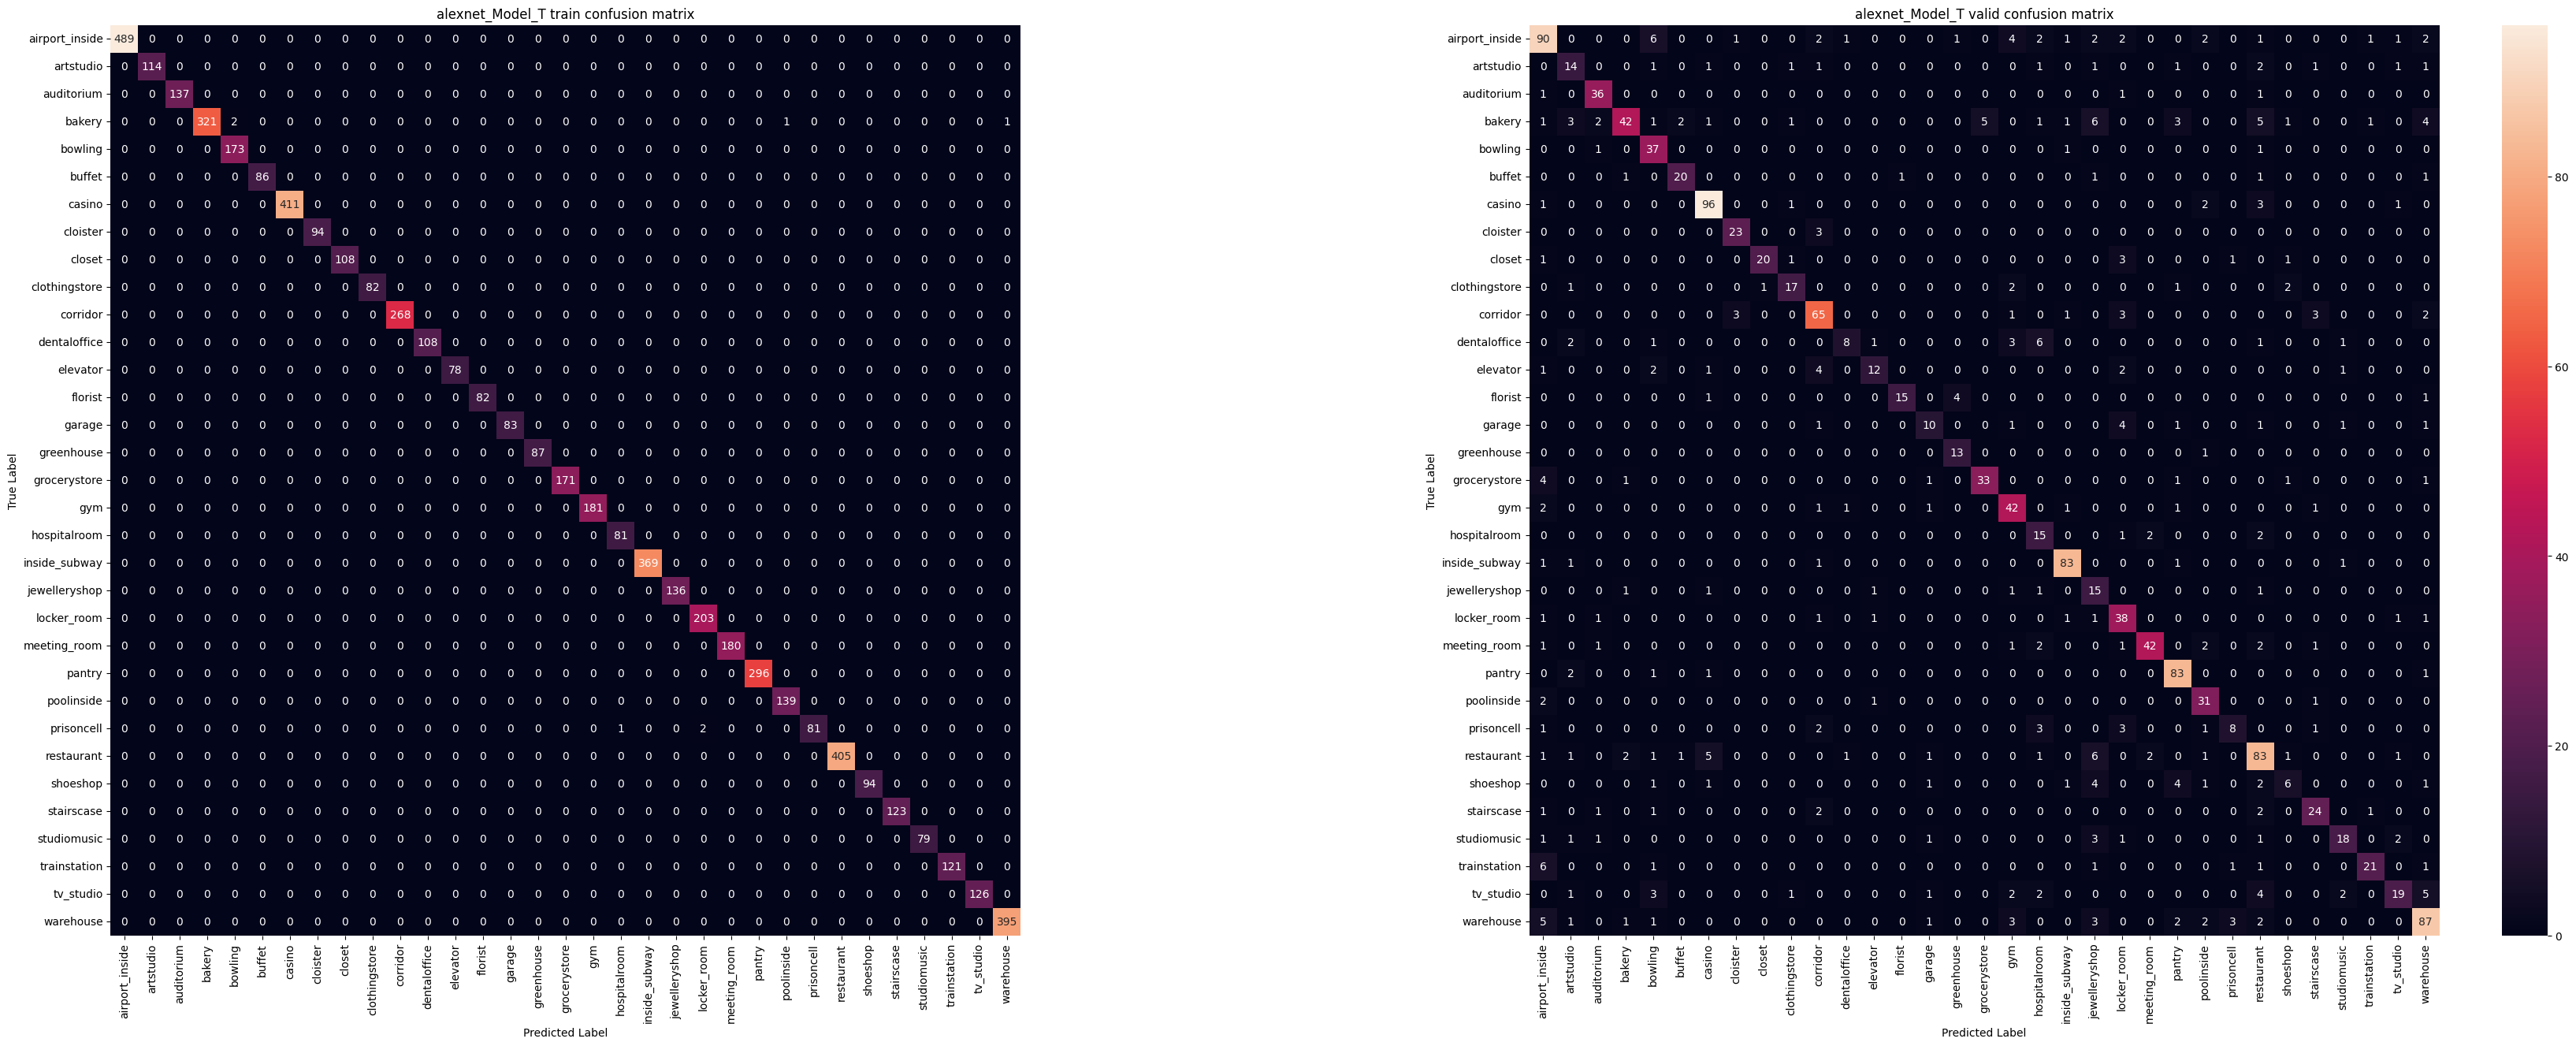

In [ ]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

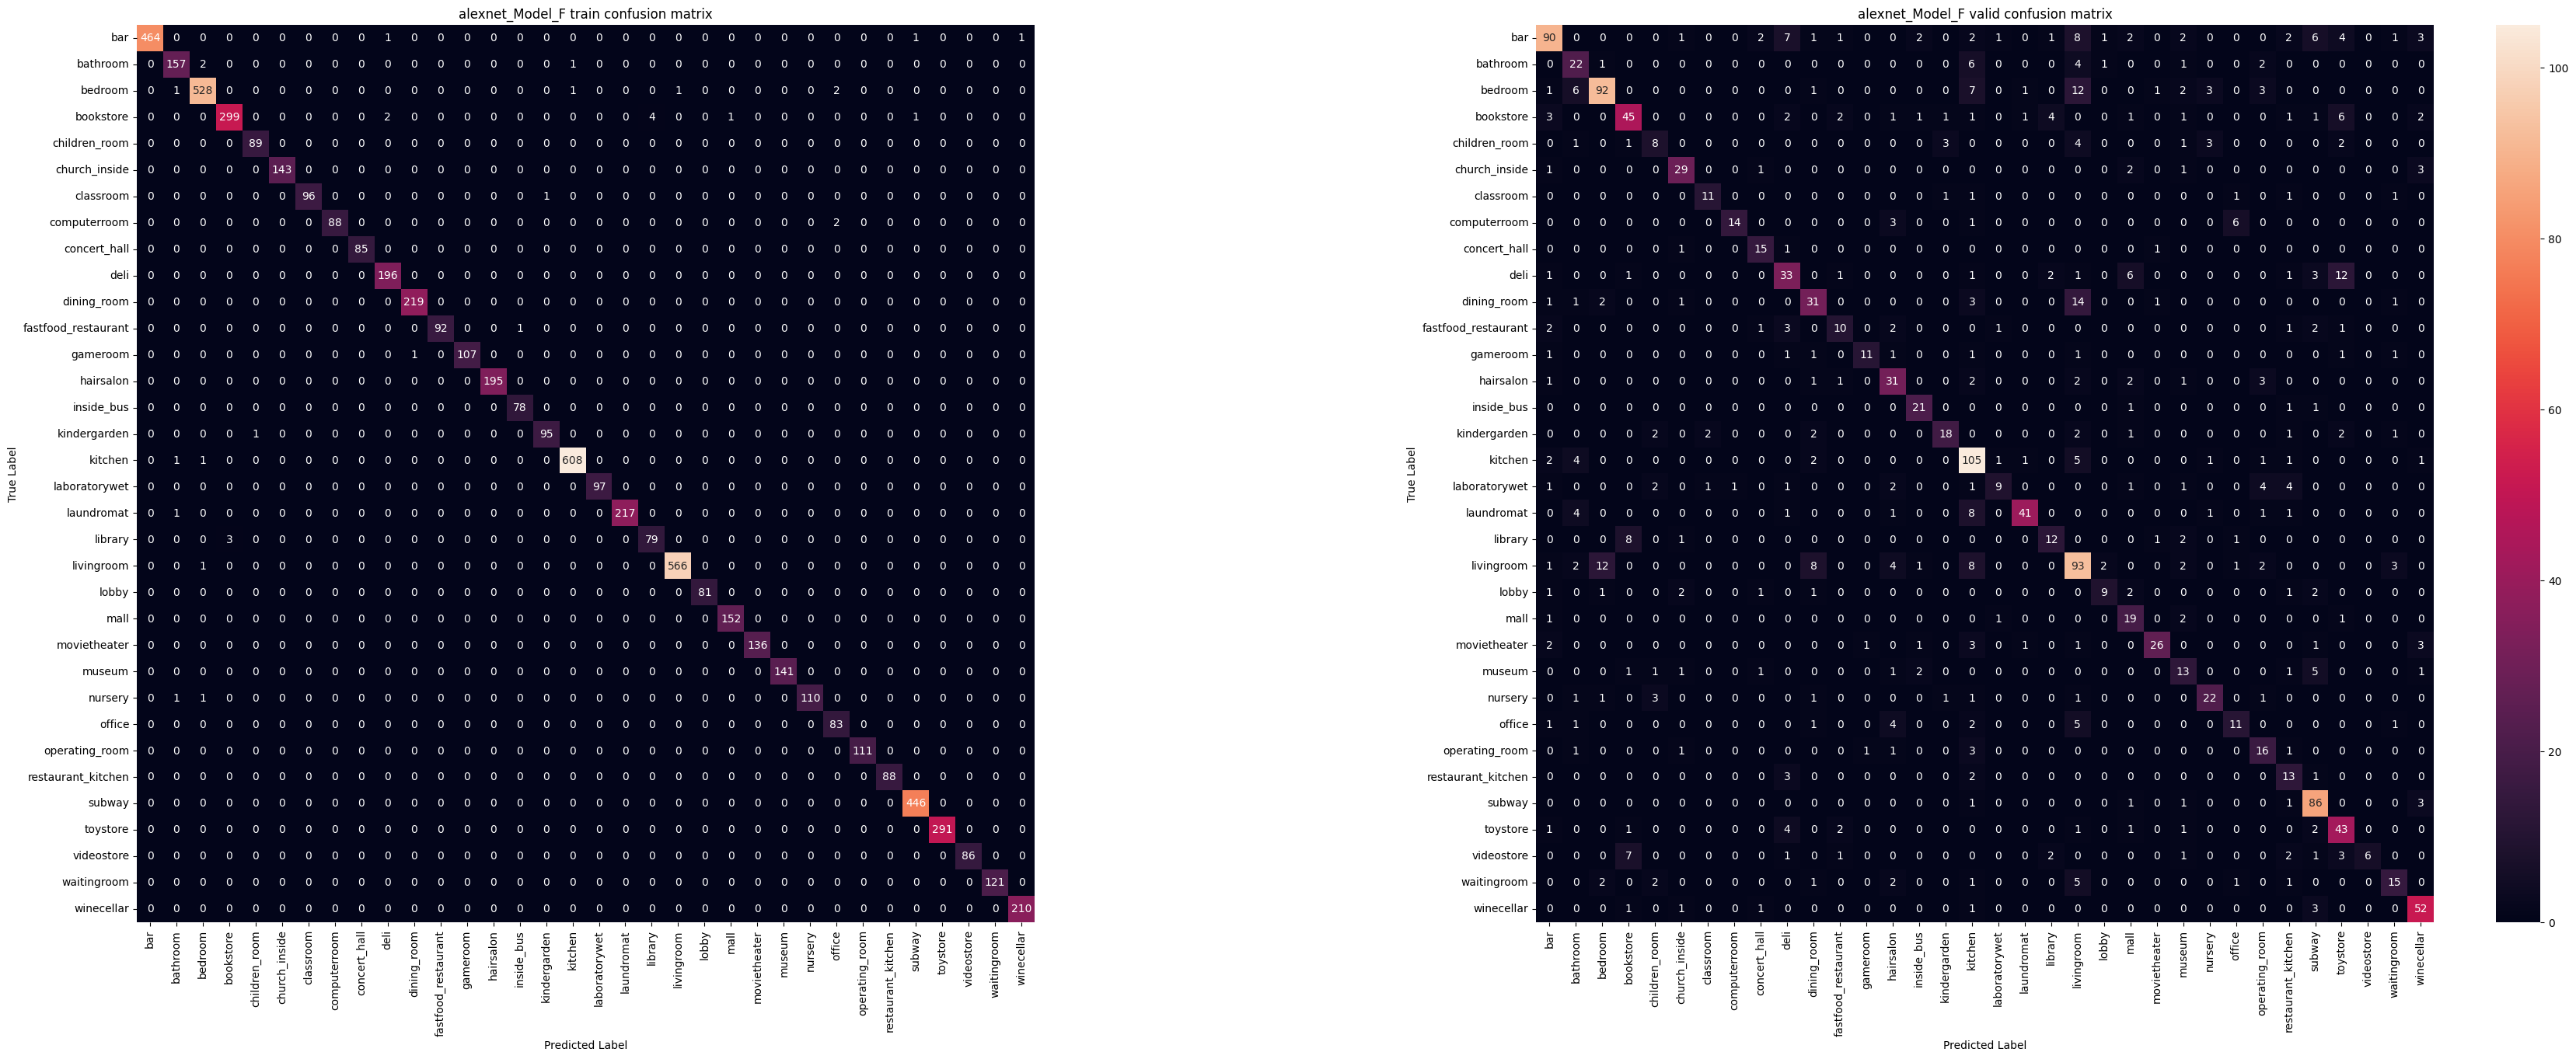

In [ ]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [ ]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [ ]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,7448,33,33,65,33,0.999931,0.537635,0.999665,0.998921,True,False,True,False,False
1,12881,54,41,54,54,0.487647,0.999909,0.998225,0.999722,False,True,True,True,True
2,14839,64,64,54,64,0.999321,0.897744,0.999767,0.999998,True,False,True,False,False
3,960,3,20,3,3,0.519269,0.949093,0.999192,0.973872,False,True,True,True,True
4,3935,10,4,10,10,0.820601,1.000000,0.999528,0.999927,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12491,11864,51,20,51,51,0.705511,1.000000,0.999999,1.000000,False,True,True,True,True
12492,6741,29,60,29,29,0.796884,0.999999,0.999980,0.999999,False,True,True,True,True
12493,7046,30,50,30,30,0.437961,0.999969,0.999066,0.999994,False,True,True,True,True
12494,11037,46,46,58,46,0.999466,0.427908,0.999863,0.999997,True,False,True,False,False


In [ ]:
len(df_results[(df_results['Decision']!=df_results['flag'])])

18

In [ ]:
len(df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9) & (df_results['Softmax_F']>df_results['Softmax_T']) & (df_results['flag']==False)])

4

In [ ]:
len(df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9) & (df_results['Softmax_F']<df_results['Softmax_T']) & (df_results['flag']==True)])

5

In [ ]:
df_results[(df_results['Softmax_decision']<0.7)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
1103,7962,34,59,34,34,0.999743,1.000000,0.999976,0.516846,False,True,True,False,True
1320,5526,20,20,51,20,0.998383,0.514658,0.998702,0.637331,True,False,True,True,False
1422,10658,44,44,8,44,0.999985,0.612652,0.996433,0.580591,True,False,True,False,False
1509,4013,11,11,51,11,0.951239,0.777713,0.861349,0.678549,True,False,True,False,False
3625,12673,54,55,54,54,0.950096,0.999917,0.996805,0.521564,False,True,True,True,True
5668,12611,54,41,54,54,0.992022,0.999931,0.985248,0.666395,False,True,True,False,True
6192,2813,7,7,51,7,0.965690,0.999965,0.977550,0.606449,True,False,True,True,False
6311,14228,60,60,29,60,0.908978,0.996473,0.965270,0.507561,True,False,True,True,False
7064,7522,33,33,34,33,0.999992,0.996351,0.999318,0.672546,True,False,True,False,False
7654,857,2,46,2,2,0.737338,0.999993,0.969070,0.508263,False,True,True,False,True


In [ ]:
df_results[(df_results['Decision']!=df_results['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
370,13794,59,59,61,61,1.000000,0.999950,0.608839,0.919087,True,False,False,True,False
1103,7962,34,59,34,34,0.999743,1.000000,0.999976,0.516846,False,True,True,False,True
1320,5526,20,20,51,20,0.998383,0.514658,0.998702,0.637331,True,False,True,True,False
2977,5572,20,20,29,20,0.931142,0.933621,0.968286,0.794733,True,False,True,True,False
4275,14162,60,60,51,60,0.969115,0.999849,0.996375,0.735356,True,False,True,True,False
5220,793,2,66,2,2,0.999867,1.000000,0.984746,0.762456,False,True,True,False,True
5668,12611,54,41,54,54,0.992022,0.999931,0.985248,0.666395,False,True,True,False,True
6192,2813,7,7,51,7,0.965690,0.999965,0.977550,0.606449,True,False,True,True,False
6311,14228,60,60,29,60,0.908978,0.996473,0.965270,0.507561,True,False,True,True,False
7654,857,2,46,2,2,0.737338,0.999993,0.969070,0.508263,False,True,True,False,True


In [ ]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,4983,18,18,2,18,0.990413,0.765883,0.978892,1.000000,True,False,True,False,False
1,8964,37,41,45,59,0.793667,0.740074,0.845583,0.774557,False,False,False,True,False
2,13642,59,59,0,59,1.000000,0.976560,0.999985,0.999985,True,False,True,False,False
3,5992,22,41,57,41,0.790622,0.643130,0.937040,0.992175,False,False,False,False,False
4,14833,64,64,54,64,0.952947,0.778902,0.983288,0.980895,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3119,4652,15,7,15,56,0.638075,0.314273,0.574783,0.779660,False,True,False,True,True
3120,899,2,46,2,2,0.999887,1.000000,0.669644,0.825134,False,True,True,True,True
3121,2966,7,39,16,59,0.310188,0.574810,0.415064,0.991537,False,False,False,True,False
3122,836,2,18,2,35,0.758046,0.898956,0.619395,0.998038,False,True,False,False,True


In [ ]:
df_results_v[(df_results_v['Softmax_decision']<0.7)&(df_results_v['Decision']==df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
31,3227,8,64,8,8,0.487280,0.999491,0.911487,0.654163,False,True,True,True,True
71,13244,57,41,8,37,0.565392,0.996094,0.454312,0.570692,False,False,False,True,True
75,12562,54,50,35,38,0.619345,0.554417,0.214867,0.525129,False,False,False,True,True
100,1477,4,33,54,24,0.259715,0.988414,0.660338,0.500556,False,False,False,False,False
110,15385,66,66,65,59,0.967111,0.999527,0.566328,0.571607,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3005,9999,41,41,45,41,0.890309,0.931374,0.452194,0.573834,True,False,True,False,False
3023,12332,53,55,52,38,0.235886,0.494760,0.718558,0.649033,False,False,False,True,True
3025,13995,60,60,56,60,0.986403,0.791337,0.562033,0.605051,True,False,True,False,False
3047,2796,7,24,8,7,0.669625,0.973946,0.233582,0.696993,False,False,True,False,False


In [ ]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])& (df_results_v['Target']==54)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
10,12442,54,37,54,37,0.703043,0.316607,0.367263,0.969670,False,True,False,False,True
67,12523,54,4,54,4,0.751431,0.999144,0.759415,0.696361,False,True,False,False,True
142,12633,54,66,54,66,0.878136,0.991773,0.970686,0.999927,False,True,False,False,True
168,12701,54,38,35,24,0.298309,0.361114,0.278218,0.980471,False,False,False,False,True
207,12564,54,4,8,4,0.987778,0.916116,0.884058,0.675383,False,False,False,False,True
218,12524,54,4,54,4,0.964888,0.954678,0.987274,0.975551,False,True,False,False,True
223,12618,54,4,54,54,0.993845,0.999999,0.949703,0.680398,False,True,True,False,True
318,12858,54,41,54,51,0.848403,0.858688,0.446299,0.659095,False,True,False,False,True
410,12526,54,41,54,31,0.620580,0.693048,0.408959,0.986390,False,True,False,False,True
473,12668,54,41,35,4,0.213233,0.371472,0.640103,0.963131,False,False,False,False,True


In [ ]:
len(df_results_v[(df_results_v['Decision']!=df_results_v['flag'])])

582

In [ ]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

In [ ]:
target_counts = df['Target'].value_counts()
target_counts 

54    50
4     35
20    33
0     25
2     24
      ..
48     1
25     1
22     1
17     1
13     1
Name: Target, Length: 66, dtype: int64

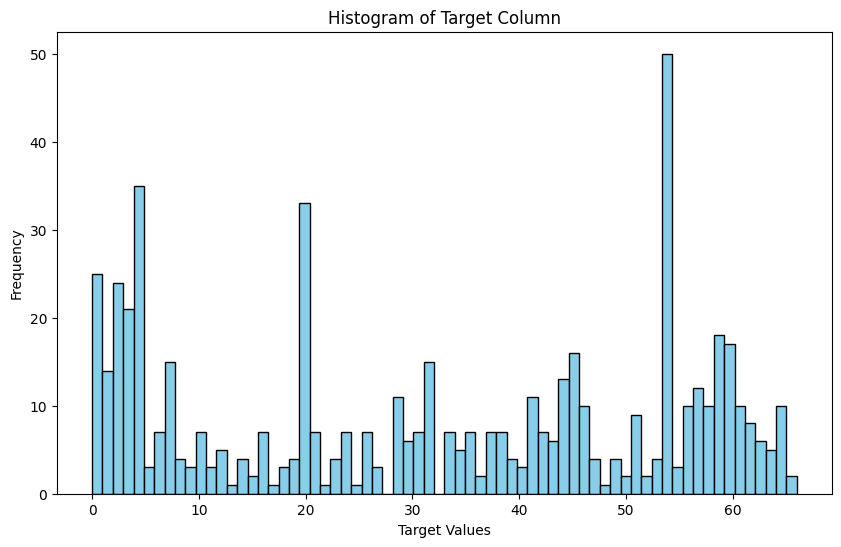

In [ ]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [ ]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag']) & (df_results_v['Match_F']==False) &(df_results_v['Match_T']==False )&(df_results_v['Match_0']==False)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
13,7356,32,24,1,24,0.467187,0.248742,0.404727,0.985902,False,False,False,False,True
26,5413,20,66,1,59,0.188435,0.432909,0.992664,0.775905,False,False,False,True,False
32,352,0,63,10,24,0.592070,0.518325,0.471499,0.666557,False,False,False,False,True
37,5153,19,41,53,6,0.598388,0.257349,0.314166,0.898189,False,False,False,False,True
54,4710,16,60,1,11,0.545200,0.819534,0.336268,0.998179,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3057,1551,4,24,51,24,0.394084,0.404425,0.889225,0.739277,False,False,False,True,False
3088,14596,63,40,51,56,0.526420,0.551087,0.578813,0.784326,False,False,False,True,False
3097,653,1,41,57,37,0.429720,0.328244,0.501029,0.999771,False,False,False,False,True
3112,7366,32,41,58,58,0.936007,0.837527,0.695729,0.778253,False,False,False,False,True


In [ ]:
len(df_results_v[(df_results_v['Decision']!=df_results_v['flag']) & (df_results_v['Softmax_decision']<0.9) & (df_results_v['Softmax_F']>df_results_v['Softmax_T']) & (df_results_v['flag']==False)])

48

In [ ]:
len(df_results_v[(df_results_v['Decision']!=df_results_v['flag']) & (df_results_v['Softmax_decision']<0.9) & (df_results_v['Softmax_F']<df_results_v['Softmax_T']) & (df_results_v['flag']==True)])

112

In [ ]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag']) & (df_results_v['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
13,10843,45,37,45,45,0.633887,0.976848,0.577745,0.809757,False,True,True,False,True
25,12755,54,31,54,54,0.264603,0.966687,0.477829,0.842208,False,True,True,False,True
37,1055,3,20,3,3,0.983278,0.999991,0.887182,0.550113,False,True,True,False,True
83,3011,7,7,56,56,0.655313,0.848712,0.971656,0.722684,True,False,False,True,False
107,15461,66,4,54,24,0.650325,0.956571,0.549055,0.498809,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3041,11272,47,24,10,24,0.551766,0.935892,0.522115,0.659437,False,False,False,True,False
3069,10343,43,6,43,43,0.358589,0.976459,0.886412,0.768987,False,True,True,False,True
3088,5588,20,55,3,1,0.342877,0.837941,0.569998,0.795452,False,False,False,True,False
3115,14919,65,59,0,34,0.498826,0.735304,0.433387,0.805054,False,False,False,False,True


In [ ]:
#全部模型裝在一起的表現
def total_model_combine_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_growth = model_0(data)
            softmax_0=torch.softmax(out_growth, dim=1)

            out_T = model_T(data)
            softmax_T=torch.softmax(out_T, dim=1)

            out_F = model_F(data)
            softmax_F=torch.softmax(out_F, dim=1)

         
            
            for s0,st,sf,d in zip(softmax_0,softmax_T,softmax_F,data):
               
                st_max=torch.max(st).item()
                sf_max=torch.max(sf).item()

                out_decision=model_decision(d.unsqueeze(0))
                _, pred = torch.max(out_decision, dim = 1) 
                softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
                
                if(softmax_decision<0.7):
                    # st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
                    # sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
                
                    if(sf_max>st_max):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                else:
                   
                    if(pred==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [ ]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(0.04656689675171859, 0.9958386683738797, 6583, 5913)

In [ ]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(4.518771191717873, 0.6187580025608195, 1622, 1502)

In [ ]:
model_0_embed= copy.deepcopy(model_0)
for i in range(7):
    model_0_embed.classifier[i]=nn.Identity()
# model_0_embed.classifier[5]=nn.Identity()


In [ ]:
model_0_embed

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Identity()
    (1): Identity()
    (2): Identity()
    (3): Identity()
    (4): Identity()
    

In [ ]:
ALL=set(range(67))
targetT=list(ALL-set(targetF))

In [ ]:
mean_features_dict_T = {class_idx: [] for class_idx in targetT}
for data, target, idx in Tdl:
    with torch.no_grad():
        data, target = data.to(device), target.to(device)
        out=model_0_embed(data)
        for feature, class_idx in zip(out, target):
            if class_idx not in  targetF:
                mean_features_dict_T[class_idx.item()].append(feature.cpu().view(-1))

# 计算每个 targetF 类别的平均特征向量
mean_features_T = {}
for class_idx, features_list in mean_features_dict_T.items():
    mean_features_T[class_idx] = torch.mean(torch.stack(features_list), dim=0)


In [ ]:
mean_features_dict_F = {class_idx: [] for class_idx in targetF}
for data, target, idx in Fdl:
    with torch.no_grad():
        data, target = data.to(device), target.to(device)
        out=model_0_embed(data)
        for feature, class_idx in zip(out, target):
            if class_idx in targetF:
                mean_features_dict_F[class_idx.item()].append(feature.cpu().view(-1))

# 计算每个 targetF 类别的平均特征向量
mean_features_F = {}
for class_idx, features_list in mean_features_dict_F.items():
    mean_features_F[class_idx] = torch.mean(torch.stack(features_list), dim=0)

In [ ]:
import torch.nn.functional as F
def calculate_sim_max_idx(f,mean_features):
    k=0
    max=0
    for i in mean_features.keys():
        sim=F.cosine_similarity(f,mean_features[i], dim=0)
        if(max<sim):
            k=i
            max=sim
    return k,max

In [ ]:
tl=[]
with torch.no_grad():
    for data,target,idx in valid_dl:
        data,target=data.to(device),target.to(device)
        
        for t,d in zip(target,data):
            if(t==50):
                out=model_0_embed(d.unsqueeze(0))
                tl.append(out.cpu())

In [ ]:
F.cosine_similarity(tl[0][0],mean_features_T[15],dim=0)

tensor(0.2967)

In [ ]:
F.cosine_similarity(tl[0][0],mean_features_F[50],dim=0)

tensor(0.4804)

In [ ]:
k=0
max=0
for key in mean_features_T.keys():
    result=F.cosine_similarity(tl[2][0],mean_features_T[key],dim=0)
    if(max<result):
        max=result
        k=key
max,k

(tensor(0.4172), 21)

In [ ]:
k=0
max=0

for key in mean_features_F.keys():
    result=F.cosine_similarity(tl[2][0],mean_features_F[key],dim=0)
    if(max<result):
        max=result
        k=key

max,k

(tensor(0.4640), 50)

In [ ]:
len(mean_features_dict_T[0])

489

In [ ]:
len(tl[0][0])

9216

In [ ]:
tl[2]

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.3350, 0.0048, 0.0000]])

In [ ]:
import torch.nn.functional as F
sum_all=0
sum_F=0
sum_T=0
with torch.no_grad():
    for data,target,idx in train_dl:
 
        data,target=data.to(device),target.to(device)

        out = model_0_embed(data)
     
        for data,t in zip(out,target):
            # print(len(o))
            k_T,similarity_T = calculate_sim_max_idx(data.cpu().view(-1), mean_features_T)
            k_F,similarity_F = calculate_sim_max_idx(data.cpu().view(-1), mean_features_F)
 
            if(similarity_T>similarity_F):
                if(t not in targetF):
                    sum_all+=1
                else:
                    sum_F+=1
            else:
                if(t in targetF):
                    sum_all+=1
                else:
                    sum_T+=1

    sum_all=sum_all/train_size
sum_all,sum_F,sum_T

(0.8561139564660691, 927, 871)

In [ ]:
import torch.nn.functional as F
sum_all=0
sum_F=0
sum_T=0
with torch.no_grad():
    for data,target,idx in valid_dl:
 
        data,target=data.to(device),target.to(device)

        out = model_0_embed(data)
     
        for data,t in zip(out,target):
            # print(len(o))
            k_T,similarity_T = calculate_sim_max_idx(data.cpu().view(-1), mean_features_T)
            k_F,similarity_F = calculate_sim_max_idx(data.cpu().view(-1), mean_features_F)
 
            if(similarity_T>similarity_F):
                if(t not in targetF):
                    sum_all+=1
                else:
                    sum_F+=1
            else:
                if(t in targetF):
                    sum_all+=1
                else:
                    sum_T+=1

    sum_all=sum_all/valid_size
sum_all,sum_F,sum_T

(0.7903329065300896, 325, 330)

In [ ]:
def choose_with_model(data):
    out_decision=model_decision(data)
    _, pred = torch.max(out_decision, dim = 1) 
    softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
    if(pred==0):
        return 0
    else:
        return 1

In [ ]:
def choose_with_softmax(data):
    out_T = model_T(data)
    softmax_T=torch.softmax(out_T, dim=1)

    out_F = model_F(data)
    softmax_F=torch.softmax(out_F, dim=1)

    st_max=torch.max(softmax_T).item()
    sf_max=torch.max(softmax_F).item()

    if(sf_max>st_max):
        return 0
    else:
        return 1

In [ ]:
def choose_with_sim(out,mean_features_T,mean_features_F):
    k_T,similarity_T = calculate_sim_max_idx(out.cpu().view(-1), mean_features_T)
    k_F,similarity_F = calculate_sim_max_idx(out.cpu().view(-1), mean_features_F)
    if(similarity_T>similarity_F):
        return 1
    else:
        return 0


In [ ]:
import torch.nn.functional as F
sum_all=0
sum_T=0
sum_F=0
list_T=[]
list_F=[]
with torch.no_grad():
    for data,target,idx in valid_dl:
        data,target=data.to(device),target.to(device)
        out = model_0_embed(data)
     
        for d,out,t in zip(data,out,target):
            sim_decision=choose_with_sim(out,mean_features_T,mean_features_F)
            soft_decision=choose_with_softmax(d.unsqueeze(0))
            mo_decision=choose_with_model(d.unsqueeze(0))
            total_decision=sim_decision+soft_decision+mo_decision

            if(total_decision>=2):
                if(t not in targetF):
                    sum_all+=1
                else:
                   sum_T+=1
                   list_F.append(t.item())
            else:
                if(t in targetF):
                    sum_all+=1
                else:
                   sum_F+=1
                   list_T.append(t.item())

    sum_all=sum_all/valid_size
sum_all,sum_T,sum_F

(0.8223431498079385, 295, 260)

In [ ]:
#全部模型裝在一起的表現
def total_model_decision_evaluate(data_dl,size,model_0_embed,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out = model_0_embed(data)
            # softmax_0=torch.softmax(out_growth, dim=1)
            # _, y_pred = torch.max(out_growth, dim = 1) 
            
            for d,out,t in zip(data,out,target):

                sim_decision=choose_with_sim(out,mean_features_T,mean_features_F)
                soft_decision=choose_with_softmax(d.unsqueeze(0))
                mo_decision=choose_with_model(d.unsqueeze(0))
                total_decision=sim_decision+soft_decision+mo_decision

                if(total_decision>=2):
                    out_T = model_T(d.unsqueeze(0))
                    outputs.append(out_T)
                    sum_T+=1
                else:
                    out_F = model_F(d.unsqueeze(0))
                    outputs.append(out_F)
                    sum_F+=1
            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [ ]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_decision_evaluate(train_dl,train_size,model_0_embed,model_T,model_F)
total_loss,accu,sum_F,sum_T

(0.6990675309341444, 0.9629481434058899, 6420, 6076)

In [ ]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_decision_evaluate(valid_dl,valid_size,model_0_embed,model_T,model_F)
total_loss,accu,sum_F,sum_T

(4.113216730757651, 0.6123559539052497, 1585, 1539)